# 02b · Generalised Linear Models (GLMs)

Notebooks 01 and 02 look different (a line vs. an S-curve, MSE vs. cross-entropy), but they are **the same recipe** with one ingredient swapped. This notebook names that recipe and uses it to build a third model, **Poisson regression**, for counts (e.g. number of claims per policy).

**Contents**

1. Side by side: what linear and logistic regression have in common
2. The recipe: three ingredients
3. Why we need a link function
4. The loss is always minus the log-likelihood
5. The gradient is always (prediction − target) × input
6. One proof for all: convexity
7. One gradient-descent function fits all three models
8. Worked example: Poisson regression for claim counts
9. Interpreting the coefficients

Softmax regression (notebook 04) is one more member of the family.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(7)

## 1. Side by side

| | Linear regression (01) | Logistic regression (02) |
|---|---|---|
| target $y$ | any real number | 0 or 1 |
| linear score | $z = \boldsymbol{\theta}^\top\mathbf{x}$ | $z = \boldsymbol{\theta}^\top\mathbf{x}$ |
| prediction $h_{\boldsymbol{\theta}}(\mathbf{x})$ | $z$ | $\sigma(z)$ |
| what the prediction means | mean of $y$ | $P(y=1)$ = mean of $y$ |
| noise model | Gaussian | Bernoulli |
| loss | MSE = $-\log$ Gaussian likelihood | cross-entropy = $-\log$ Bernoulli likelihood |
| gradient | $\frac1m\mathbf{X}^\top(h - \mathbf{y})$ | $\frac1m\mathbf{X}^\top(h - \mathbf{y})$ |

Three things stayed the same:
- a **linear score** $z = \boldsymbol{\theta}^\top\mathbf{x}$,
- the prediction is the **mean** of $y$ (for 0/1 labels the mean *is* $P(y=1)$),
- the gradient has the form **(prediction − target) × input**.

Two things changed, and they always change together:
- the **distribution** of $y$ (Gaussian → Bernoulli),
- the **function** that turns $z$ into a prediction (identity → sigmoid).

## 2. The recipe: three ingredients

A GLM is specified by answering three questions.

1. **What kind of number is $y$?** Pick a distribution for $y$ given $\mathbf{x}$ that produces that kind of number, with mean $\mu$.
   - real numbers → Gaussian
   - 0/1 → Bernoulli
   - counts $0, 1, 2, \dots$ → **Poisson**
2. **Linear score.** $z = \boldsymbol{\theta}^\top\mathbf{x}$ (always the same).
3. **Link.** Connect the two: $\mu = g^{-1}(z)$, where $g^{-1}$ maps any real number into the allowed range of $\mu$. ($g$ itself is called the *link function*; $g^{-1}$ is the *inverse link*, the one we actually compute with.)

| model | $y$ | distribution | allowed $\mu$ | prediction $\mu = g^{-1}(z)$ | link $g(\mu) = z$ |
|---|---|---|---|---|---|
| linear regression | real | Gaussian | $(-\infty, \infty)$ | $z$ | identity: $\mu$ |
| logistic regression | 0/1 | Bernoulli | $(0, 1)$ | $\sigma(z) = \frac{1}{1+e^{-z}}$ | logit: $\log\frac{\mu}{1-\mu}$ |
| **Poisson regression** | count | Poisson | $(0, \infty)$ | $e^{z}$ | log: $\log\mu$ |

That's all a GLM is: **a linear score, pushed through a function so it lands in the right range, used as the mean of the right distribution.**

## 3. Why we need a link

The linear score $z$ can be any real number. The mean $\mu$ often cannot:
- a probability must be in $(0,1)$,
- an expected number of claims must be $> 0$.

The inverse link squashes or stretches $\mathbb{R}$ onto exactly the allowed range, so the model can **never** predict something impossible, no matter what $\mathbf{x}$ is.

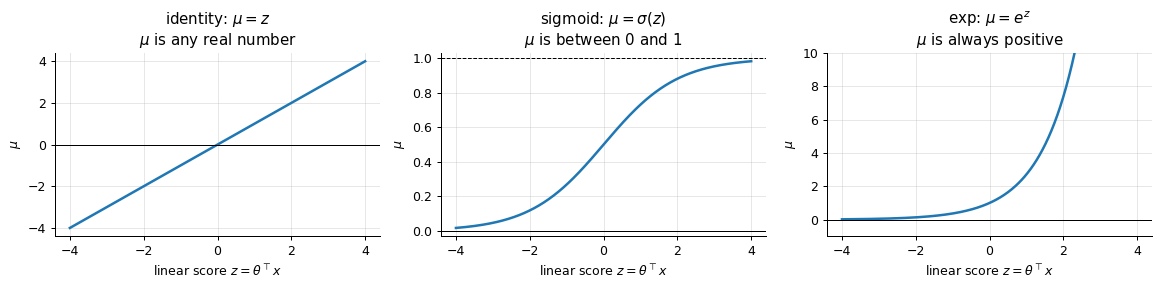

In [2]:
z = np.linspace(-4, 4, 300)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, f, name, rng_txt in [(axes[0], z, r"identity: $\mu = z$", "any real number"),
                             (axes[1], 1 / (1 + np.exp(-z)), r"sigmoid: $\mu = \sigma(z)$", "between 0 and 1"),
                             (axes[2], np.exp(z), r"exp: $\mu = e^z$", "always positive")]:
    ax.plot(z, f, lw=2); ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"{name}\n$\\mu$ is {rng_txt}"); ax.set_xlabel(r"linear score $z=\theta^\top x$"); ax.set_ylabel(r"$\mu$")
axes[1].axhline(1, color="k", lw=0.8, ls="--"); axes[2].set_ylim(-1, 10)
plt.tight_layout(); plt.show()

## 4. The loss is always minus the log-likelihood

Same rule as in notebooks 01 and 02: **write the probability of each observed $y$ under the model, take $-\log$, average.** Per example, with $\mu = g^{-1}(\boldsymbol{\theta}^\top\mathbf{x})$:

| distribution | $P(y \mid \mu)$ | per-example loss $\ell = -\log P$ (dropping constants) |
|---|---|---|
| Gaussian ($\sigma = 1$) | $\frac{1}{\sqrt{2\pi}}e^{-(y-\mu)^2/2}$ | $\frac12(\mu - y)^2$ → **MSE** |
| Bernoulli | $\mu^y(1-\mu)^{1-y}$ | $-y\log\mu - (1-y)\log(1-\mu)$ → **cross-entropy** |
| Poisson | $\frac{\mu^y e^{-\mu}}{y!}$ | $\mu - y\log\mu$ → **Poisson loss** |

"Dropping constants" means dropping terms that don't depend on $\boldsymbol{\theta}$ (like $\log\sqrt{2\pi}$ or $\log y!$), which don't move the minimum.

**The Poisson distribution** in one line: if events happen independently at an average rate of $\mu$ per period, the number $y$ that happens in one period has $P(y) = \mu^y e^{-\mu}/y!$. Its mean is $\mu$ and, notably, its **variance is also $\mu$**: the more claims you expect, the more the actual count varies.

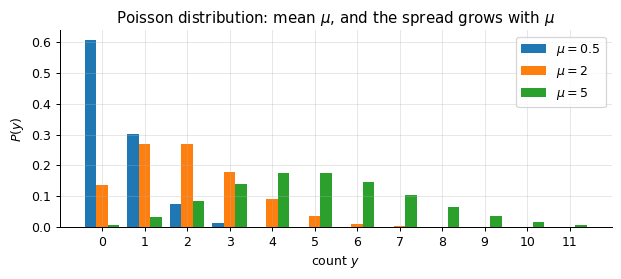

In [3]:
from scipy.stats import poisson
fig, ax = plt.subplots(figsize=(7, 3.2))
k = np.arange(0, 12)
for i, mu in enumerate([0.5, 2, 5]):
    ax.bar(k + (i - 1) * 0.27, poisson.pmf(k, mu), width=0.27, label=rf"$\mu={mu}$")
ax.set_xlabel("count $y$"); ax.set_ylabel("$P(y)$"); ax.set_xticks(k); ax.legend()
ax.set_title("Poisson distribution: mean $\\mu$, and the spread grows with $\\mu$")
plt.tight_layout(); plt.show()

## 5. The gradient is always (prediction − target) × input

Write $z = \boldsymbol{\theta}^\top\mathbf{x}$ and use the chain rule $\frac{\partial\ell}{\partial\theta_j} = \frac{\partial\ell}{\partial z}\cdot\frac{\partial z}{\partial\theta_j} = \frac{\partial\ell}{\partial z}\cdot x_j$. So we only need $\partial\ell/\partial z$ for each model. Put $\mu$ in terms of $z$ first:

**Gaussian.** $\mu = z$, $\;\ell = \frac12(z - y)^2$, $\;\frac{\partial\ell}{\partial z} = z - y = \mu - y$.

**Bernoulli.** $\mu = \sigma(z)$. Shown in notebook 02, section 5: $\;\frac{\partial\ell}{\partial z} = \mu - y$.

**Poisson.** $\mu = e^z$, so $\log\mu = z$ and $\;\ell = e^z - y\,z$, $\;\frac{\partial\ell}{\partial z} = e^z - y = \mu - y$.

In all three cases:

$$
\boxed{\frac{\partial\ell}{\partial z} = \mu - y
\qquad\Longrightarrow\qquad
\nabla_{\boldsymbol{\theta}} J = \frac{1}{m}\sum_{i=1}^m \big(\mu^{(i)} - y^{(i)}\big)\,\mathbf{x}^{(i)} = \frac1m \mathbf{X}^\top(\boldsymbol{\mu} - \mathbf{y})}
$$

**Why does it come out so clean?** Because we paired each distribution with its "natural" link (the **canonical link**): identity for Gaussian, logit for Bernoulli, log for Poisson. With these pairs, the derivative of the link and the derivative of the log-likelihood cancel each other out. (Other pairings are allowed, e.g. a log link with a Gamma distribution for claim *amounts*, but the gradient gets an extra factor.)

## 6. One proof for all: convexity

All three losses can be written in the same shape. With $z = \boldsymbol{\theta}^\top\mathbf{x}$:

$$
\ell(z) = A(z) - y\,z, \qquad
\begin{array}{c|c|c|c}
 & A(z) & A'(z) = \mu & A''(z) \\\hline
\text{Gaussian} & \tfrac12 z^2 & z & 1 \\
\text{Bernoulli} & \log(1 + e^{z}) & \sigma(z) & \mu(1-\mu) \\
\text{Poisson} & e^{z} & e^{z} & \mu
\end{array}
$$

(Check Gaussian: $\frac12 z^2 - yz = \frac12(z-y)^2 - \frac12y^2$, the MSE up to a constant. Check Bernoulli: $\log(1+e^z) - yz$ is exactly the cross-entropy written in terms of $z$.)

Two facts fall out immediately:

1. **Gradient.** $\ell'(z) = A'(z) - y = \mu - y$ (section 5 again, in one line).
2. **Curvature.** $\ell''(z) = A''(z)$, and in every row $A''(z) \ge 0$. It is, in fact, the **variance** of $y$: $1$ for the Gaussian (we set $\sigma=1$), $\mu(1-\mu)$ for Bernoulli, $\mu$ for Poisson. A variance can't be negative.

Going from $z$ to $\boldsymbol{\theta}$ (same step as notebooks 01 and 02):

$$
\nabla^2 J(\boldsymbol{\theta}) = \frac1m\sum_{i=1}^m A''(z^{(i)})\,\mathbf{x}^{(i)}\mathbf{x}^{(i)\top},
\qquad
\mathbf{v}^\top\nabla^2 J\,\mathbf{v} = \frac1m\sum_{i=1}^m \underbrace{A''(z^{(i)})}_{\ge 0}\big(\mathbf{v}^\top\mathbf{x}^{(i)}\big)^2 \ge 0 .
$$

So **every GLM with its canonical link has a convex loss**: any point with zero gradient is a global minimum, and gradient descent can't get stuck. $\blacksquare$

The one-parameter picture from notebook 01's warm-up still holds: $\ell(z)$ is a bowl in $z$, with the bottom where $\mu = y$.

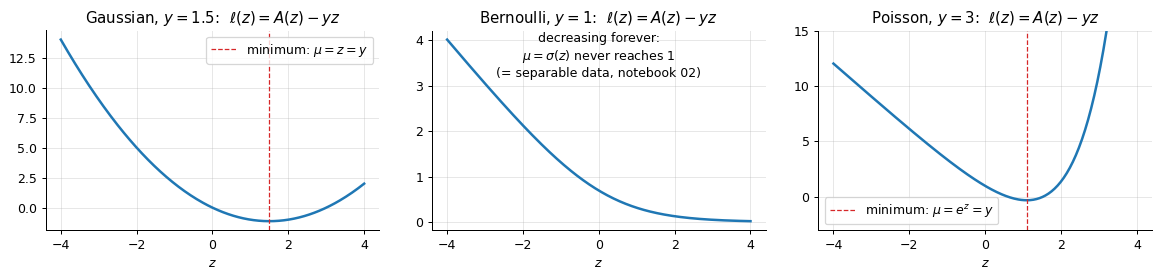

In [4]:
z = np.linspace(-4, 4, 300)
losses = [("Gaussian, $y=1.5$", 0.5 * z**2 - 1.5 * z),
          ("Bernoulli, $y=1$", np.log1p(np.exp(z)) - 1 * z),
          ("Poisson, $y=3$", np.exp(z) - 3 * z)]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, (name, l) in zip(axes, losses):
    ax.plot(z, l, lw=2); ax.set_title(name + r":  $\ell(z)=A(z)-yz$"); ax.set_xlabel("$z$")
axes[0].axvline(1.5, color="C3", ls="--", lw=1, label=r"minimum: $\mu=z=y$"); axes[0].legend()
axes[2].axvline(np.log(3), color="C3", ls="--", lw=1, label=r"minimum: $\mu=e^z=y$"); axes[2].legend()
axes[1].text(0, 3.2, "decreasing forever:\n$\\mu=\\sigma(z)$ never reaches 1\n(= separable data, notebook 02)", ha="center")
axes[2].set_ylim(-3, 15)
plt.tight_layout(); plt.show()

## 7. One gradient-descent function fits all three models

Since the gradient is always $\frac1m\mathbf{X}^\top(\boldsymbol{\mu} - \mathbf{y})$, a GLM fitter only needs to know the **inverse link**. Everything else is identical.

                 model |   true theta |    our fit_glm |        sklearn
     gaussian (linear) |   [0.5, 1.0] |  [0.505 1.008] |  [0.505 1.008]
  bernoulli (logistic) |   [0.5, 1.0] |  [0.508 0.988] |  [0.508 0.988]
               poisson |   [0.5, 1.0] |  [0.533 0.996] |  [0.533 0.996]


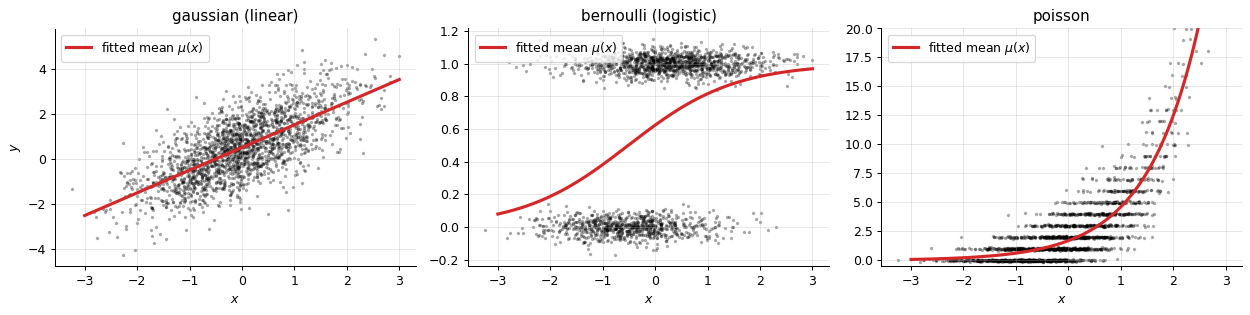

In [5]:
inverse_links = {
    "gaussian (linear)":   lambda z: z,
    "bernoulli (logistic)": lambda z: 1 / (1 + np.exp(-z)),
    "poisson":             lambda z: np.exp(z),
}

def fit_glm(X, y, inv_link, alpha=0.1, n_iters=5000):
    theta = np.zeros(X.shape[1])
    for _ in range(n_iters):
        mu = inv_link(X @ theta)                        # prediction = mean of y
        theta -= alpha * X.T @ (mu - y) / len(y)        # (prediction - target) x input
    return theta

# Same x, three kinds of target, all generated from z = 0.5 + 1.0 x
m = 2000
x = rng.normal(0, 1, m)
X = np.c_[np.ones(m), x]
z_true = 0.5 + 1.0 * x
targets = {
    "gaussian (linear)":   z_true + rng.normal(0, 1, m),
    "bernoulli (logistic)": rng.binomial(1, 1 / (1 + np.exp(-z_true))),
    "poisson":             rng.poisson(np.exp(z_true)),
}

from sklearn.linear_model import LinearRegression, LogisticRegression, PoissonRegressor
sk_models = {"gaussian (linear)": LinearRegression(),
             "bernoulli (logistic)": LogisticRegression(C=1e10),
             "poisson": PoissonRegressor(alpha=0, max_iter=1000)}

print(f"{'model':>22} | {'true theta':>12} | {'our fit_glm':>14} | {'sklearn':>14}")
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
g = np.linspace(-3, 3, 200)
for ax, (name, y) in zip(axes, targets.items()):
    th = fit_glm(X, y, inverse_links[name])
    sk = sk_models[name].fit(x[:, None], y)
    sk_th = np.r_[np.ravel(sk.intercept_), np.ravel(sk.coef_)]
    print(f"{name:>22} | {'[0.5, 1.0]':>12} | {str(th.round(3)):>14} | {str(sk_th.round(3)):>14}")
    ax.scatter(x, y + (rng.normal(0, 0.05, m) if name != "gaussian (linear)" else 0), s=3, alpha=0.25, color="k")
    ax.plot(g, inverse_links[name](th[0] + th[1] * g), "C3", lw=2.5, label=r"fitted mean $\mu(x)$")
    ax.set_title(name); ax.set_xlabel("$x$"); ax.legend(loc="upper left")
axes[0].set_ylabel("$y$"); axes[2].set_ylim(-0.5, 20)
plt.tight_layout(); plt.show()

The same six lines of `fit_glm` recover the true parameters in all three cases and agree with scikit-learn. The only thing that changed between models is one function.

(For the Poisson model we kept $\alpha$ small: because $e^z$ grows fast, a large step can overshoot badly. Standardising the features helps, exactly as in notebook 01.)

## 8. Worked example: Poisson regression for claim counts

**Problem.** For each policyholder we know their age and the number of claims they made over the last 5 years ($y = 0, 1, 2, \dots$). We want the **expected number of claims** as a function of age, e.g. to price the policy. (The data below is synthetic.)

**Why not linear regression?**
- A straight line can predict a **negative** number of claims.
- Effects on counts are naturally **multiplicative** ("10 more years of age → 40 % fewer claims"), not additive ("→ 0.3 fewer claims", which is huge for a low-risk group and tiny for a high-risk one).
- The noise is not constant: counts vary more where the mean is larger (Poisson variance $= \mu$).

**Poisson regression** answers all three: $\mu = e^{\theta_0 + \theta_1\,\text{age}}$ is always positive, and $\theta_1$ acts multiplicatively (section 9).

slope per year of age: -0.0491   (true: -0.05)


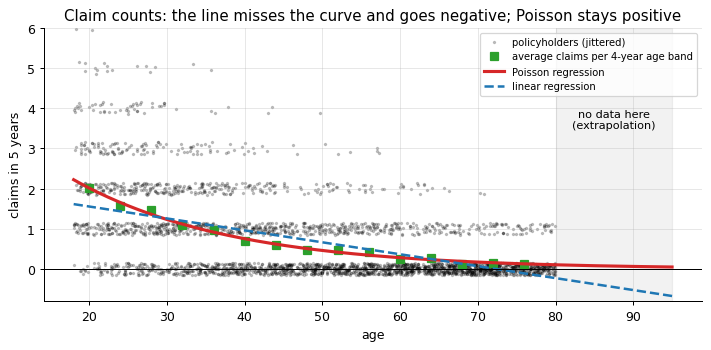

prediction at age 90:  linear = -0.52 claims   Poisson = 0.06 claims


In [6]:
m = 3000
age = rng.uniform(18, 80, m)
mu_true = np.exp(0.8 - 0.05 * (age - 18))            # young drivers: ~2.2 claims in 5 years; 80-year-olds: ~0.1
claims = rng.poisson(mu_true)

# standardise age for gradient descent, then convert the slope back to "per year"
a_mean, a_sd = age.mean(), age.std()
Xa = np.c_[np.ones(m), (age - a_mean) / a_sd]
th = fit_glm(Xa, claims, inverse_links["poisson"], alpha=0.1, n_iters=5000)
slope_per_year = th[1] / a_sd
intercept_age0 = th[0] - th[1] * a_mean / a_sd       # so that mu = exp(intercept_age0 + slope_per_year * age)
print(f"slope per year of age: {slope_per_year:.4f}   (true: -0.05)")

lin = LinearRegression().fit(age[:, None], claims)

g = np.linspace(18, 95, 300)
bins = np.arange(18, 81, 4); centers = (bins[:-1] + bins[1:]) / 2
bin_means = [claims[(age >= lo) & (age < hi)].mean() for lo, hi in zip(bins[:-1], bins[1:])]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(age, claims + rng.uniform(-0.15, 0.15, m), s=3, alpha=0.2, color="k", label="policyholders (jittered)")
ax.plot(centers, bin_means, "s", color="C2", ms=6, label="average claims per 4-year age band")
ax.plot(g, np.exp(intercept_age0 + slope_per_year * g), "C3", lw=2.5, label="Poisson regression")
ax.plot(g, lin.intercept_ + lin.coef_[0] * g, "C0", lw=2, ls="--", label="linear regression")
ax.axhline(0, color="k", lw=0.8); ax.axvspan(80, 95, color="gray", alpha=0.1)
ax.text(87.5, 3.5, "no data here\n(extrapolation)", ha="center", fontsize=9)
ax.set_xlabel("age"); ax.set_ylabel("claims in 5 years"); ax.set_ylim(-0.8, 6); ax.legend(loc="upper right", fontsize=8)
ax.set_title("Claim counts: the line misses the curve and goes negative; Poisson stays positive")
plt.tight_layout(); plt.show()
print(f"prediction at age 90:  linear = {lin.predict([[90]])[0]:+.2f} claims   Poisson = {np.exp(intercept_age0 + slope_per_year * 90):.2f} claims")

**Exposure (common in insurance).** If policyholders were observed for different lengths of time $t^{(i)}$, the expected count is rate × time: $\mu^{(i)} = t^{(i)}\,e^{\boldsymbol{\theta}^\top\mathbf{x}^{(i)}}$, i.e. $\log\mu^{(i)} = \log t^{(i)} + \boldsymbol{\theta}^\top\mathbf{x}^{(i)}$. The term $\log t^{(i)}$ is added to the score with a fixed coefficient of 1 (an **offset**). In scikit-learn the equivalent is to fit $y/t$ with `sample_weight=t`.

## 9. Interpreting the coefficients

The link decides how a coefficient acts. Increase $x_j$ by one unit, others fixed: the score $z$ goes up by $\theta_j$. What happens to the prediction?

| model | link | $+1$ in $x_j$ does this to the prediction | name |
|---|---|---|---|
| linear | identity | **adds** $\theta_j$ to $\mu$ | slope |
| logistic | logit | **multiplies the odds** $\frac{\mu}{1-\mu}$ by $e^{\theta_j}$ | odds ratio |
| Poisson | log | **multiplies $\mu$** by $e^{\theta_j}$ | rate ratio |

*Proof for Poisson:* $\mu(x_j + 1) = e^{\dots + \theta_j(x_j + 1)} = e^{\dots + \theta_j x_j}\cdot e^{\theta_j} = \mu(x_j)\cdot e^{\theta_j}$.

For the claims example:

In [7]:
print(f"theta_age = {slope_per_year:.4f} per year")
print(f"  +1 year of age  -> expected claims x {np.exp(slope_per_year):.3f}  ({100 * (np.exp(slope_per_year) - 1):+.1f} %)")
print(f"  +10 years of age -> expected claims x {np.exp(10 * slope_per_year):.3f}  ({100 * (np.exp(10 * slope_per_year) - 1):+.1f} %)")
print(f"  e.g. age 25 -> 35: {np.exp(intercept_age0 + slope_per_year * 25):.2f} -> {np.exp(intercept_age0 + slope_per_year * 35):.2f} claims")
print(f"       age 60 -> 70: {np.exp(intercept_age0 + slope_per_year * 60):.2f} -> {np.exp(intercept_age0 + slope_per_year * 70):.2f} claims   (same % drop, smaller absolute drop)")

theta_age = -0.0491 per year
  +1 year of age  -> expected claims x 0.952  (-4.8 %)
  +10 years of age -> expected claims x 0.612  (-38.8 %)
  e.g. age 25 -> 35: 1.57 -> 0.96 claims
       age 60 -> 70: 0.28 -> 0.17 claims   (same % drop, smaller absolute drop)


## Summary

- A **GLM** = linear score $z = \boldsymbol{\theta}^\top\mathbf{x}$ + inverse link $\mu = g^{-1}(z)$ that puts the prediction in the right range + a distribution for $y$ with mean $\mu$.
- Linear regression (Gaussian, identity), logistic regression (Bernoulli, logit) and Poisson regression (Poisson, log) are all GLMs.
- Loss = minus the log-likelihood: MSE, cross-entropy, Poisson loss $\mu - y\log\mu$.
- With the canonical link the gradient is always $\frac1m\mathbf{X}^\top(\boldsymbol{\mu} - \mathbf{y})$ and the loss is always convex (its curvature is the variance of $y$).
- So one gradient-descent function fits all of them; only the inverse link changes.
- Coefficients: additive (identity), odds ratio (logit), rate ratio (log).
- Other members: **softmax** regression (categorical $y$, notebook 04), **Gamma** regression with log link (positive amounts such as claim cost), **Tweedie** (total cost per policy, many exact zeros).